
**Context:**  
Carbon dioxide (CO2) emissions are the main driver of global climate change. The Our World in Data dataset provides detailed CO2 emissions data, including sources (coal, oil, gas, cement), economic intensity (CO2 per GDP), and per-capita metrics, enabling historical analyses and cross-country comparisons.

**Problem:**  
Although emissions data is widely available, understanding which countries and sectors contribute the most, how emissions evolved over time, and how economic intensity varies is still limited without structured exploratory analysis and clear visualizations.

**Objective:**  
Perform an exploratory analysis of global CO2 emissions to identify:  
- Countries with the highest absolute and per-capita emissions.  
- Historical evolution of total emissions and emissions by source.  
- Growth or reduction trends across different regions.  
- Relationship between emissions, GDP, and population, highlighting economic intensity.

**Main Deliverables:**  
- Ranking of top emitting countries in absolute and per-capita terms.  
- Global and regional historical evolution of emissions.  
- Analysis of sources driving CO2 growth or reduction.  
- Charts and maps to support interpretation and strategic insights.  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid')


In [2]:
import pandas as pd
from iso3166 import countries
from babel import Locale
import numpy as np

# Load main dataset (local file with OWID online fallback)
from pathlib import Path
DATA_PATH = Path('owid-co2-data.csv')
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_csv('https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv')
df = df[['country','year','iso_code','population','gdp','co2','co2_per_capita',
         'co2_growth_prct','coal_co2','oil_co2','gas_co2','cement_co2']]

# Configure Portuguese locale (kept for optional translated-country analysis)
pt = Locale('pt')

# Convert ISO alpha-3 to Portuguese country name while preserving selected aggregates
def iso3_to_pt_keep_aggregates(iso3, country_name):
    # Translate specific aggregates
    if country_name == 'World':
        return 'Mundo'
    if country_name == 'European Union (27)':
        return 'Uni?o Europeia (27)'

    # Individual countries
    if pd.isna(iso3):
        return None
    try:
        return pt.territories[countries.get(iso3).alpha2]
    except:
        # Other aggregates or unrecognized codes -> keep original name
        return country_name

# Create country_pt translated column
df['country_pt'] = df.apply(lambda row: iso3_to_pt_keep_aggregates(row['iso_code'], row['country']), axis=1)

# Check result
df[['country','iso_code','country_pt']].head(15)


,country,iso_code,country_pt
0,Afghanistan,AFG,Afeganistão
1,Afghanistan,AFG,Afeganistão
2,Afghanistan,AFG,Afeganistão
3,Afghanistan,AFG,Afeganistão
4,Afghanistan,AFG,Afeganistão
5,Afghanistan,AFG,Afeganistão
6,Afghanistan,AFG,Afeganistão
7,Afghanistan,AFG,Afeganistão
8,Afghanistan,AFG,Afeganistão
9,Afghanistan,AFG,Afeganistão


In [3]:
# List all unique values in 'country' that contain aggregate-related keywords
keywords = ['World', 'European', 'Union', 'OECD', 'Asia', 'Africa', 'Americas', 'EU27']
aggregates_found = [c for c in df['country'].unique() if any(k in c for k in keywords)]

print("Aggregates found in the dataset:")
for c in aggregates_found:
    print(c)


Aggregates found in the dataset:
Africa
Africa (GCP)
Asia
Asia (GCP)
Asia (excl. China and India)
Central African Republic
European Union (27)
European Union (28)
Non-OECD (GCP)
OECD (GCP)
OECD (Jones et al.)
South Africa
World


### CO2 Dataset Cleaning and Preparation

- **Incomplete data removal:** dropped rows without country or year information.  
- **Missing-value handling:** replaced NaNs in source-level emissions (coal, oil, gas, cement) with 0, and filled missing population and GDP using linear interpolation.  
- **Ordering and standardization:** sorted data by country and year, and converted columns to appropriate types (integer for year, float for population, GDP, and CO2).  
- **Creation of additional metrics:**  
  - `co2_per_capita` - per-capita emissions.  
  - `co2_per_gdp` - emissions intensity per GDP unit.  
  - `total_energy_co2` - sum of main fossil-fuel emissions.  

These adjustments prepare the dataset for exploratory analysis and CO2 global-emissions visualizations.


In [4]:
df = df.dropna(subset=['country', 'year']).copy()
df[['coal_co2','oil_co2','gas_co2','cement_co2']] = df[['coal_co2','oil_co2','gas_co2','cement_co2']].fillna(0)

df = df.sort_values(['country','year']).reset_index(drop=True)
for col in ['population','gdp']:
    df[col] = df.groupby('country')[col].transform(lambda s: s.interpolate(method='linear', limit_direction='both'))

df['year'] = df['year'].astype(int)
for col in ['population','gdp','co2']:
    df[col] = df[col].astype(float)

df['co2_per_gdp'] = np.where(df['gdp'] > 0, df['co2'] / df['gdp'], np.nan)
df['co2_per_capita'] = np.where(df['population'] > 0, (df['co2'] * 1_000_000) / df['population'], np.nan)
df['total_energy_co2'] = df['coal_co2'] + df['oil_co2'] + df['gas_co2'] + df['cement_co2']
df.shape


(50411, 15)

In [5]:
latest_year = int(df['year'].max())

# Filter latest year and only countries with a valid ISO code (avoid regions/aggregates by mistake)
latest = df[(df['year'] == latest_year) & df['iso_code'].fillna('').str.len().eq(3)].copy()

# Select top 10 emitters by CO2, drop null-emission rows, and sort descending
top10 = latest[['country','co2','co2_per_capita','year']]     .dropna(subset=['co2'])     .sort_values('co2', ascending=False)     .head(10)

# Format numbers with thousands separator and decimal precision
top10_formatted = top10.style.format({
    'co2': '{:,.0f}',                # Million tons, no decimals
    'co2_per_capita': '{:,.2f}'      # Tons per capita, 2 decimals

})

top10_formatted


,country,co2,co2_per_capita,year
9933,China,"12,289",8.66,2024
48007,United States,"4,904",14.20,2024
21762,India,"3,193",2.20,2024
38314,Russia,"1,781",12.29,2024
23812,Japan,962,7.77,2024
21937,Indonesia,812,2.87,2024
22662,Iran,793,8.66,2024
40289,Saudi Arabia,692,20.38,2024
43038,South Korea,584,11.29,2024
18319,Germany,572,6.77,2024


## Insights

- **Latest analyzed year:** 2024.
- **Historical evolution of global emissions:** from **9 Mt in 1750** to **38,599 Mt in 2024**, an increase of **~430,000%**, reflecting industrial growth and expansion of fossil-fuel use.
- **Global population growth:** from ~0.75 billion in 1750 to ~8.16 billion in 2024 (+983%).
- **Per-capita emissions:** declined from ~12 t/person in 1750 to ~4.7 t/person in 2024, indicating that absolute emissions growth is partially diluted by population growth.
- **Total fossil energy in 2024:** 37,758 Mt CO2, representing the **largest share of global emissions**, confirming that fossil fuels still dominate the energy mix.
- **Trend:** persistent growth in global emissions, with temporary slowdowns and fluctuations, but fossil-fuel contribution remains high.


,Year,Population (millions),Total CO2 (Gt),Total fossil energy (Gt)
0,1750,"753,279,296",9,9
1,2024,"8,161,972,574","38,599","37,758"


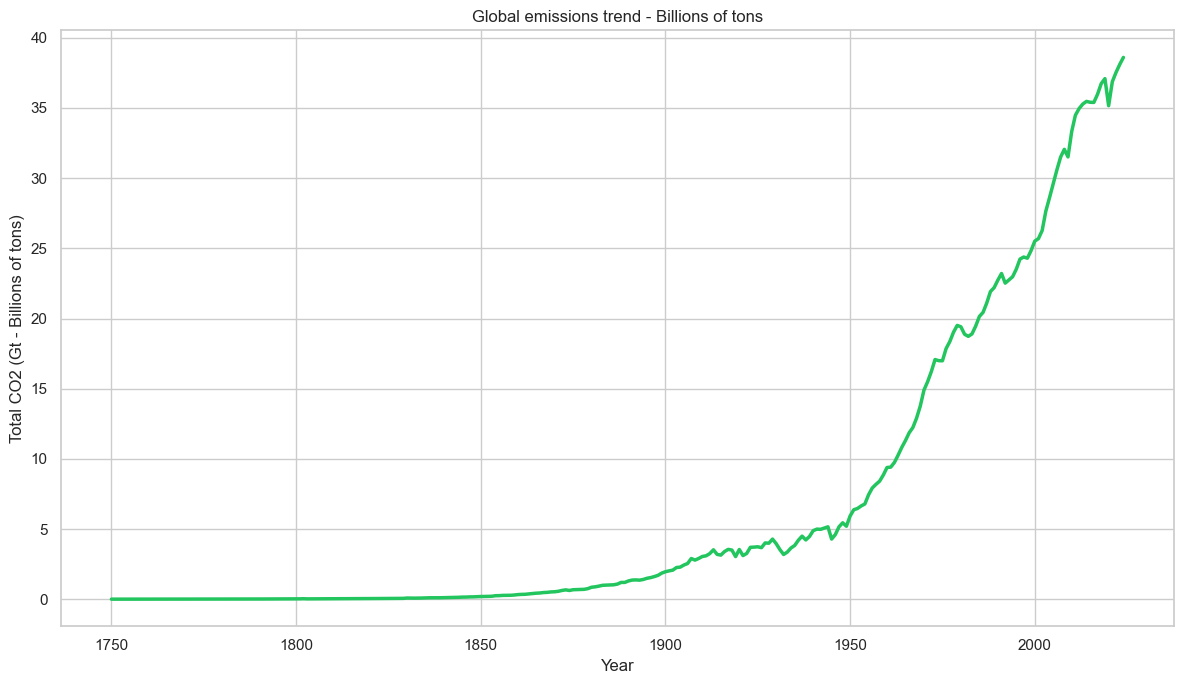

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Select global data
world = df[df['country'] == 'World'][[
    'year', 'co2', 'population', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'total_energy_co2'
]].copy()

world = world.sort_values('year')

# Compute CO2 per capita
world['co2_per_capita'] = np.where(
    world['population'] > 0,
    (world['co2'] * 1_000_000) / world['population'],
    np.nan
)

# --- Build chart with billion-ton (Gt) axis ---
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(world['year'], world['co2'] / 1_000, color='#22c55e', linewidth=2.5, label='Total global CO2')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total CO2 (Gt - Billions of tons)')
plt.title('Global emissions trend - Billions of tons')
fig.tight_layout()

# --- Build summary table ---
summary = pd.DataFrame({
    'Year': [world['year'].iloc[0], world['year'].iloc[-1]],
    'Population (millions)': [world['population'].iloc[0], world['population'].iloc[-1]],
    'Total CO2 (Gt)': [world['co2'].iloc[0], world['co2'].iloc[-1]],
    'Total fossil energy (Gt)': [world['total_energy_co2'].iloc[0], world['total_energy_co2'].iloc[-1]]
})

# Format with thousands separator
summary_formatted = summary.style.format({
    'Population (millions)': '{:,.0f}',
    'Total CO2 (Gt)': '{:,.0f}',
    'Total fossil energy (Gt)': '{:,.0f}'
})

summary_formatted


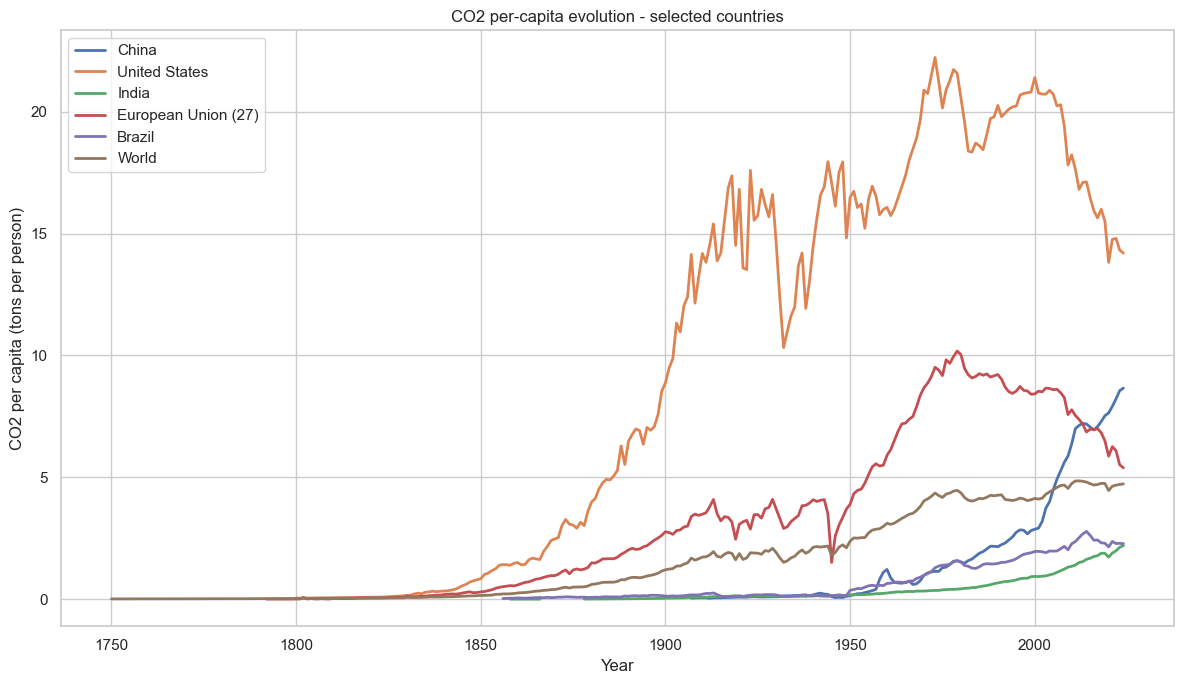

In [7]:
# List of countries and aggregates to plot
selected = ['China', 'United States', 'India', 'European Union (27)', 'Brazil', 'World']

# Keep only those present in the dataset
selected = [c for c in selected if c in df['country'].unique()]

# Filter dataframe using English country names
plot_df = df[df['country'].isin(selected)].copy()

# Build chart
fig, ax = plt.subplots(figsize=(12,7))
for c in selected:
    s = plot_df[plot_df['country'] == c]
    ax.plot(s['year'], s['co2_per_capita'], linewidth=2, label=c)

ax.set_title('CO2 per-capita evolution - selected countries')
ax.set_xlabel('Year')
ax.set_ylabel('CO2 per capita (tons per person)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()


In [8]:
# Build auxiliary table for per-capita CO2 with population
percapita_table = latest[['iso_code','country','population','co2','co2_per_capita']].copy()

# Sort by highest per-capita values
percapita_table = percapita_table.sort_values('co2_per_capita', ascending=False).head(20)

# Add readable columns
percapita_table['Population (millions)'] = percapita_table['population'] / 1_000_000
percapita_table['Total CO2 (Mt)'] = percapita_table['co2']
percapita_table['CO2 per capita (t/person)'] = percapita_table['co2_per_capita']

# Select final columns and rename
percapita_table_final = percapita_table[['country','Population (millions)','Total CO2 (Mt)','CO2 per capita (t/person)']]
percapita_table_final = percapita_table_final.rename(columns={'country':'Country'})

# Format numbers for display
percapita_table_final.style.format({
    'Population (millions)': '{:,.2f}',
    'Total CO2 (Mt)': '{:,.0f}',
    'CO2 per capita (t/person)': '{:,.2f}'
})


,Country,Population (millions),Total CO2 (Mt),CO2 per capita (t/person)
37960,Qatar,3.05,126,41.27
24865,Kuwait,4.93,130,26.25
7662,Brunei,0.46,12,26.05
4514,Bahrain,1.61,39,24.27
45799,Trinidad and Tobago,1.51,35,22.93
40289,Saudi Arabia,33.96,692,20.38
47507,United Arab Emirates,11.03,222,20.13
32410,New Caledonia,0.29,5,18.07
41538,Sint Maarten (Dutch part),0.04,1,16.55
35885,Oman,5.28,83,15.65


## Insights on CO2 per capita - Top 15 countries (2024)

- **Highest per-capita emitters:**  
  - **Qatar** leads with 41.27 t/person, followed by **Kuwait** (26.25 t/person) and **Brunei** (26.05 t/person).  
  - These countries have relatively small populations, but high dependence on fossil fuels and energy industries.

- **Countries with large populations and significant per-capita levels:**  
  - **Saudi Arabia** (20.38 t/person), **United Arab Emirates** (20.13 t/person), and the **United States** (14.20 t/person) show that per-capita intensity can remain high even with larger populations.

- **Difference between per capita and total emissions:**  
  - Some countries with high CO2 per capita have low total emissions (e.g., Brunei, Bahrain, Faroe Islands).  
  - Others, such as the United States and Saudi Arabia, combine high total CO2 with high per-capita intensity, strongly impacting the global climate.

- **Strategic insight:**  
  - CO2 per capita helps identify countries that are less efficient per person.  
  - Small, fossil-energy-rich countries may appear less relevant in total emissions, but have extremely high individual intensity.  
  - Combining total CO2 and per-capita metrics is crucial to prioritize climate policy and energy efficiency.


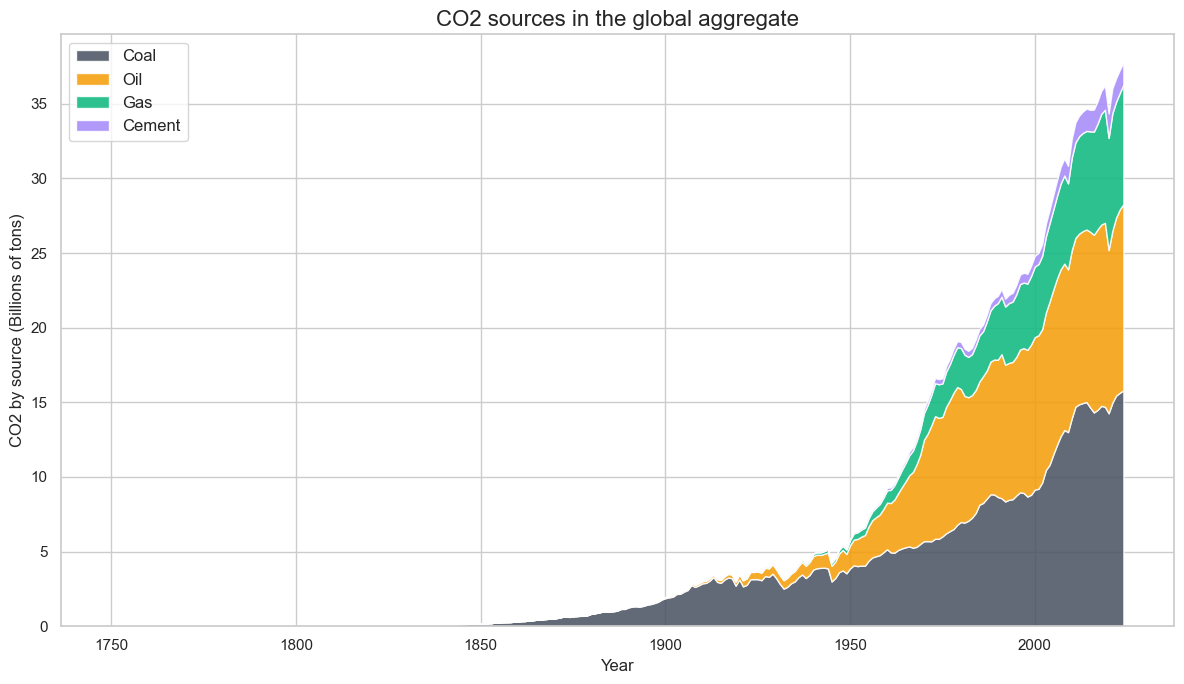

In [9]:
src = world[['year','coal_co2','oil_co2','gas_co2','cement_co2']].copy()

# Divide by 1,000 to convert Mt -> Gt
src[['coal_co2','oil_co2','gas_co2','cement_co2']] /= 1_000

fig, ax = plt.subplots(figsize=(12,7))
ax.stackplot(
    src['year'],
    src['coal_co2'], src['oil_co2'], src['gas_co2'], src['cement_co2'],
    labels=['Coal','Oil','Gas','Cement'],
    colors=['#4b5563','#f59e0b','#10b981','#a78bfa'],
    alpha=0.88
)
ax.set_title('CO2 sources in the global aggregate', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO2 by source (Billions of tons)', fontsize=12)
ax.legend(loc='upper left', fontsize=12)
fig.tight_layout()


## CO2 distribution by fossil-fuel type

### CO2 emission sources
Carbon dioxide emissions associated with energy production and industry can come from different fuel types. The contribution of each source has changed significantly over time and still shows major regional differences.

In the chart, it is possible to visualize the absolute and relative contribution of CO2 emissions by source, distinguishing coal, oil, gas, flaring, and cement production.

---

### Global historical trends
- Early industrialization was dominated by solid fuels, especially coal.  
- Coal-based industrial power generation emerged first in Europe and North America during the 1700s.  
- Only in the late 1800s did emissions associated with oil and gas begin to grow.  
- A century later, significant emissions from flaring and cement production appeared.  

Today, solid and liquid fuels dominate global emissions, although gas has a relevant contribution. Cement and flaring remain relatively small at the global level.

---

**Summary:** the evolution of CO2 sources shows a transition from near-exclusive coal use in early industrialization to a more diversified energy mix today, although solid and liquid fossil fuels still dominate global emissions.


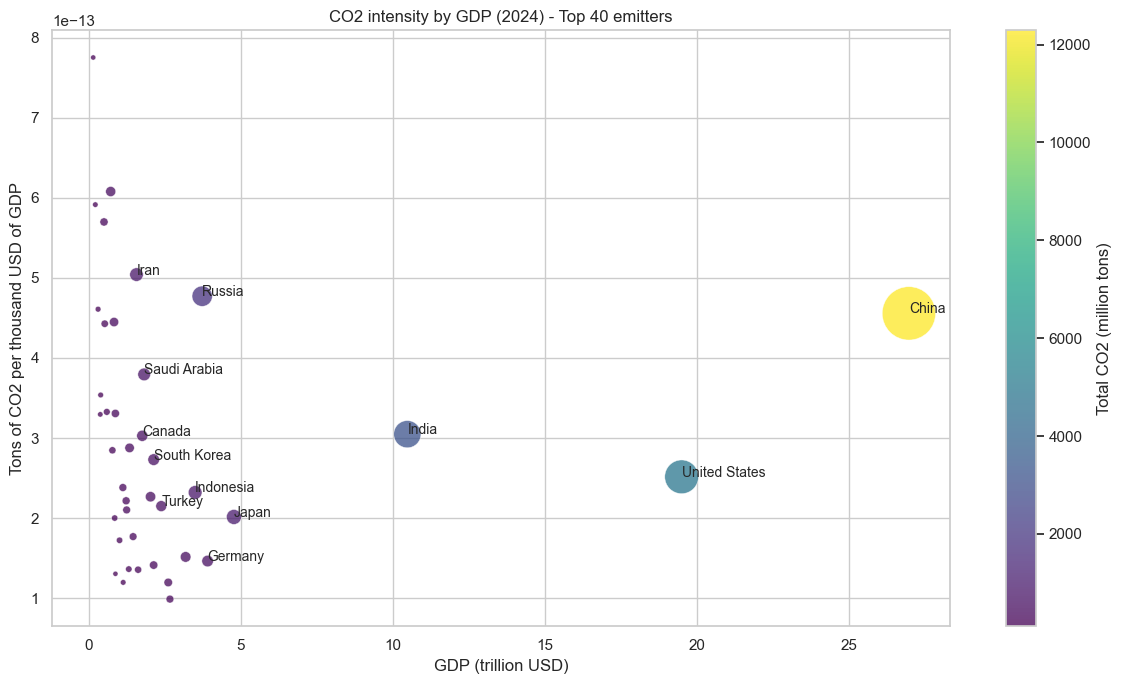

In [10]:
latest = df[(df['year'] == latest_year) & df['iso_code'].fillna('').str.len().eq(3)].copy()

# Select only relevant columns and clean inf/nan
intensity = latest[['country','co2','gdp','co2_per_gdp']].replace([np.inf, -np.inf], np.nan).dropna()
intensity = intensity[intensity['gdp'] > 0]

# Adjustment: CO2 per thousand USD (instead of per million)
intensity['co2_per_gdp_thousand_usd'] = intensity['co2_per_gdp'] / 1_000

# Top 40 emitters by total CO2
plot_df = intensity.sort_values('co2', ascending=False).head(40)

fig, ax = plt.subplots(figsize=(12,7))
sc = ax.scatter(
    plot_df['gdp'] / 1_000_000_000_000,              # GDP in trillions
    plot_df['co2_per_gdp_thousand_usd'],             # CO2 per thousand USD
    s=np.clip(plot_df['co2'], 20, None) * 0.12,      # bubble size
    c=plot_df['co2'], cmap='viridis', alpha=0.75,
    edgecolor='white', linewidth=0.4
)

# Annotate top 12 emitters
for _, r in plot_df.head(12).iterrows():
    ax.annotate(
        r['country'],
        (r['gdp'] / 1_000_000_000_000, r['co2_per_gdp_thousand_usd']),
        fontsize=10
    )

ax.set_title(f'CO2 intensity by GDP ({latest_year}) - Top 40 emitters')
ax.set_xlabel('GDP (trillion USD)')
ax.set_ylabel('Tons of CO2 per thousand USD of GDP')
fig.colorbar(sc, ax=ax, label='Total CO2 (million tons)')
fig.tight_layout()
plt.show()


In [11]:
# --- Filter latest year and countries with valid ISO code ---
latest = df[(df['year'] == latest_year) & df['iso_code'].fillna('').str.len().eq(3)].copy()

# --- Create CO2-per-GDP intensity column ---
latest['co2_per_gdp'] = np.where(latest['gdp'] > 0, latest['co2'] / latest['gdp'], np.nan)

# --- Prepare data for top emitters ---
intensity = latest[['country','co2','gdp','co2_per_gdp']].replace([np.inf, -np.inf], np.nan).dropna()
intensity = intensity[intensity['gdp'] > 0]

# --- Create tons per million USD column and scale to t/per thousand USD ---
intensity['co2_per_gdp_million_usd'] = intensity['co2_per_gdp'] * 1_000_000
intensity['co2_per_gdp_thousand_usd'] = intensity['co2_per_gdp_million_usd'] * 1_000  # more readable scale

# --- Select top 20 emitters ---
table_aux = intensity.sort_values('co2', ascending=False).head(20).copy()

# --- Format columns for table ---
table_aux['gdp_trillion'] = table_aux['gdp'] / 1_000_000_000_000
table_aux['co2_Mt'] = table_aux['co2']

# --- Select and rename final columns ---
table_final = table_aux[['country','gdp_trillion','co2_Mt','co2_per_gdp_thousand_usd']]
table_final = table_final.rename(columns={
    'country':'Country',
    'gdp_trillion':'GDP (USD trillion)',
    'co2_Mt':'Total CO2 (Mt)',
    'co2_per_gdp_thousand_usd':'CO2 / GDP (t/USD thousand)'
})

# --- Show formatted table ---
table_final.style.format({
    'GDP (USD trillion)': '{:,.2f}',
    'Total CO2 (Mt)': '{:,.0f}',
    'CO2 / GDP (t/USD thousand)': '{:,.2f}'
})


,Country,GDP (USD trillion),Total CO2 (Mt),CO2 / GDP (t/USD thousand)
9933,China,26.97,"12,289",0.46
48007,United States,19.49,"4,904",0.25
21762,India,10.48,"3,193",0.30
38314,Russia,3.73,"1,781",0.48
23812,Japan,4.77,962,0.20
21937,Indonesia,3.50,812,0.23
22662,Iran,1.57,793,0.50
40289,Saudi Arabia,1.82,692,0.38
43038,South Korea,2.14,584,0.27
18319,Germany,3.91,572,0.15


# Insights on CO2 emissions

## Largest absolute emitters
- **China:** 12,289 Mt  
- **United States:** 4,904 Mt  
- **India:** 3,193 Mt  

> These countries dominate global emissions and have the largest direct climate impact. Limiting global warming strongly depends on action in these countries.

## Economic efficiency (CO2 per GDP)
- Measured in tons of CO2 per thousand USD of GDP, indicating how many tons of CO2 are emitted to generate 1,000 dollars of economic value.
- **Low intensity:**  
  - United Kingdom (0.12), Germany (0.15), Japan (0.20)  
  - They generate more economic value per ton of CO2, indicating higher energy efficiency.
- **High intensity:**  
  - South Africa (0.61), Iran (0.50), China (0.46)  
  - Suggests dependence on fossil energy or heavy industry.

## Important context
- **High absolute emissions do not imply low economic efficiency.** A country may emit a lot of CO2 while still using energy relatively efficiently.  
- **High CO2-per-GDP intensity does not mean highest absolute impact.** Smaller economies can have high intensity but low total emissions.  
- Climate-policy assessment requires considering total emissions and GDP intensity simultaneously.

## Strategic insight
- **Major emitters:** prioritize absolute CO2 reduction to limit global warming.  
- **High-intensity countries:** focus on energy transition, industrial modernization, and efficiency, even when total emissions are not the highest.  
- Balancing absolute impact and economic efficiency is essential for effective climate policies.


In [12]:
map_df = latest[['iso_code','country','co2_per_capita','co2']].copy()
map_df = map_df[~map_df['iso_code'].str.startswith('OWID_')]
map_df = map_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['co2_per_capita'])

fig_map = px.choropleth(
    map_df,
    locations='iso_code',
    color='co2_per_capita',
    hover_name='country',
    hover_data={'co2':':.2f','co2_per_capita':':.2f'},
    color_continuous_scale='YlOrRd',
    title=f'CO2 per capita by country ({latest_year})'
)
fig_map.show()


## Conclusion - Global CO2 Analysis (2024)

The analysis of global CO2 data reveals important patterns that help explain **absolute impact and economic efficiency**:

### 1. Total emissions
- **China, the United States, and India** are the largest global emitters, representing more than 50% of CO2 among the top 20 countries.  
- These countries concentrate most of the absolute climate impact due to **large populations and intense industrialization**.

### 2. Economic intensity (CO2 / GDP)
- Developed countries such as **the United Kingdom, Germany, and Japan** show low intensity, emitting less CO2 per economic unit.  
- Emerging or heavy-industry countries, such as **South Africa, Iran, and China**, show higher intensity, reflecting **fossil-fuel dependence and lower industrial efficiency**.  
- This metric captures **economic efficiency**, but not absolute climate impact.

### 3. Individual intensity (CO2 per capita)
- Small, fossil-energy-rich countries such as **Qatar, Kuwait, and Brunei** lead the per-capita ranking with over 25 t/person.  
- Highly populated countries such as **China, India, and Brazil** have lower per-capita emissions, even while being major absolute emitters.  
- This comparison highlights that **small-population countries can have high individual intensity** but limited total impact, while major emitters dominate overall climate effects.

### 4. Strategic insight
- To **reduce global warming**, action in the **largest absolute emitters** is fundamental.  
- To **improve economic efficiency**, countries with high CO2/GDP intensity should focus on **energy transition and industrial efficiency**.  
- **CO2 per capita** helps identify countries where individual emissions are high, important for local efficiency and energy-consumption policy.

> **Summary:** Integrating total emissions, economic intensity, and per-capita metrics provides **a balanced view of global climate impact and country-level efficiency**, avoiding misleading conclusions from any single indicator.
